In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set()

In [24]:
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")

df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [25]:
#TASK1
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

In [26]:
#TASK2
df_missing = df.copy()
df_missing.loc[0:50, 'Daily_Phone_Hours'] = np.nan
df_missing.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,NaN,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,NaN,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,NaN,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,NaN,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,NaN,1.3,4,5.7,3,37,5,9.9


In [27]:
df_missing['Daily_Phone_Hours'] = df_missing['Daily_Phone_Hours'].fillna(
    df_missing['Daily_Phone_Hours'].mean()
)
df_missing.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,6.509143,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,6.509143,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,6.509143,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,6.509143,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,6.509143,1.3,4,5.7,3,37,5,9.9


count    50000.000000
mean         6.509116
std          3.170903
min          1.000000
25%          3.800000
50%          6.500000
75%          9.200000
max         12.000000
Name: Daily_Phone_Hours, dtype: float64


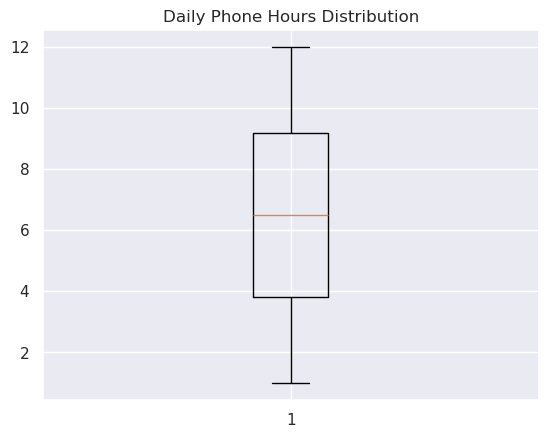

In [28]:
#TASK3
print(df['Daily_Phone_Hours'].describe())

plt.boxplot(df['Daily_Phone_Hours'])
plt.title("Daily Phone Hours Distribution")
plt.show()

In [29]:
Q1 = df['Daily_Phone_Hours'].quantile(0.25)
Q3 = df['Daily_Phone_Hours'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Daily_Phone_Hours'] < lower) | (df['Daily_Phone_Hours'] > upper)]

df_clean = df.copy()
df_clean['Daily_Phone_Hours'] = df_clean['Daily_Phone_Hours'].clip(lower, upper)

In [30]:
print(df['Daily_Phone_Hours'].describe())
print("Number of outliers:", len(outliers))

count    50000.000000
mean         6.509116
std          3.170903
min          1.000000
25%          3.800000
50%          6.500000
75%          9.200000
max         12.000000
Name: Daily_Phone_Hours, dtype: float64
Number of outliers: 0


In [41]:
#TASK4
print(df[['Daily_Phone_Hours','Work_Productivity_Score']].head())
minmax_scaler= MinMaxScaler()
print("-------------------------------------------------------------")
df_minmax = df.copy()
df_minmax[['Daily_Phone_Hours','Work_Productivity_Score']] = minmax_scaler.fit_transform(
    df_minmax[['Daily_Phone_Hours','Work_Productivity_Score']]
)

print(df_minmax[['Daily_Phone_Hours','Work_Productivity_Score']].head())

print("-------------------------------------------------------------")
standard_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[['Daily_Phone_Hours','Work_Productivity_Score']] = standard_scaler.fit_transform(
    df_zscore[['Daily_Phone_Hours','Work_Productivity_Score']]
)

# After Z-score
print(df_zscore[['Daily_Phone_Hours','Work_Productivity_Score']].head())



   Daily_Phone_Hours  Work_Productivity_Score
0                1.3                        6
1                1.2                        5
2                5.3                        5
3                5.8                        2
4                7.9                        4
-------------------------------------------------------------
   Daily_Phone_Hours  Work_Productivity_Score
0           0.027273                 0.555556
1           0.018182                 0.444444
2           0.390909                 0.444444
3           0.436364                 0.111111
4           0.627273                 0.333333
-------------------------------------------------------------
   Daily_Phone_Hours  Work_Productivity_Score
0          -1.642803                 0.172619
1          -1.674340                -0.175234
2          -0.381320                -0.175234
3          -0.223634                -1.218793
4           0.438644                -0.523087


In [44]:
#TASK5

print(df[['Daily_Phone_Hours','Social_Media_Hours','Sleep_Hours','Stress_Level','Work_Productivity_Score']].corr())
X = df_zscore[['Daily_Phone_Hours','Social_Media_Hours','Sleep_Hours','Stress_Level']]

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

                         Daily_Phone_Hours  Social_Media_Hours  Sleep_Hours  \
Daily_Phone_Hours                 1.000000            0.000591    -0.003434   
Social_Media_Hours                0.000591            1.000000    -0.000871   
Sleep_Hours                      -0.003434           -0.000871     1.000000   
Stress_Level                     -0.002762           -0.002721     0.004691   
Work_Productivity_Score          -0.002404            0.003625     0.003243   

                         Stress_Level  Work_Productivity_Score  
Daily_Phone_Hours           -0.002762                -0.002404  
Social_Media_Hours          -0.002721                 0.003625  
Sleep_Hours                  0.004691                 0.003243  
Stress_Level                 1.000000                 0.009786  
Work_Productivity_Score      0.009786                 1.000000  
Explained Variance Ratio: [0.51422779 0.29231969]
